# IMEN266 · Ch.1–3 · Class Problems 1 — Bayes' rule & discrete random variables

**How this notebook works** — every problem follows the same 5 steps:

> **Problem → Model → Analytic → Simulate & Visualize → Experiment**

The analytic answer and the simulation must agree. *That agreement — not the
instructor, not an AI — is your ground truth.*

**In-class version only:** cells marked `# TODO` are for you to complete during
class (laptop-less students: watch the live demo). A `check(...)` cell right
after tells you immediately whether your answer matches the reference value.

▶ Open in Colab: `https://colab.research.google.com/github/youngmko/imen266-2026/blob/main/ch01-03/notebooks/CP1_bayes_discrete.ipynb`

*AI policy:* you may use an AI assistant on any TODO — but you must be able to
explain every line, and the `check` must pass. See `docs/ai_usage_guide.pdf`.

In [1]:
# --- IMEN266 setup (self-contained: runs on Colab with zero installs) ---
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(2026)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11,
                     "legend.frameon": False})

def check(name, got, expected, tol=None, rel=0.05):
    """Green/red self-check. Unfinished TODOs (None / ...) do not crash."""
    if got is None or got is Ellipsis:
        print(f"[TODO] {name}: not computed yet - fill the TODO above."); return False
    g = float(got)
    ok = (abs(g-expected) <= (rel*max(abs(expected),1e-12) if tol is None else tol))
    print(f"[{'OK ' if ok else 'X  '}] {name}: got {g:.6g}   (reference {expected:.6g})")
    return ok

try:
    from ipywidgets import interact, FloatSlider, IntSlider, FloatLogSlider
    HAS_W = True
except Exception:
    HAS_W = False

def show(fn, **sliders):
    """interact() if widgets are available; otherwise draw once with defaults."""
    if HAS_W:
        interact(fn, **sliders)
    else:
        fn(**{k: getattr(v, "value", v) for k, v in sliders.items()})

print("Setup OK.  Widgets available:", HAS_W)

Setup OK.  Widgets available: True


---
## Warm-up · Series & parallel systems *(lecture pp. 7–8)*

$n$ independent components; component $i$ works with probability $p_i$.

- **Series** system works iff *all* components work: $\;R_{\text{series}}=\prod_i p_i$
- **Parallel** system works iff *at least one* works: $\;R_{\text{parallel}}=1-\prod_i(1-p_i)$

In [2]:
p = np.array([0.9, 0.8, 0.95])                      # three components

R_series   = p.prod()
R_parallel = 1 - (1 - p).prod()

# Monte-Carlo: simulate 100,000 systems
works = rng.random((100_000, len(p))) < p            # component up/down
sim_series, sim_parallel = works.all(axis=1).mean(), works.any(axis=1).mean()

print(f"series:   analytic {R_series:.4f}   simulated {sim_series:.4f}")
print(f"parallel: analytic {R_parallel:.4f}   simulated {sim_parallel:.4f}")

series:   analytic 0.6840   simulated 0.6849
parallel: analytic 0.9990   simulated 0.9991


In [3]:
def warmup(n=3, p_each=0.9):
    ps = np.full(n, p_each)
    ks = np.arange(1, n + 1)
    plt.figure()
    plt.plot(ks, [p_each**k for k in ks], "o-", label="series $p^n$")
    plt.plot(ks, [1-(1-p_each)**k for k in ks], "s-", label="parallel $1-(1-p)^n$")
    plt.xlabel("number of components n"); plt.ylabel("P(system works)")
    plt.title(f"Redundancy helps, chaining hurts  (p = {p_each})")
    plt.ylim(0, 1.02); plt.legend(); plt.show()

show(warmup,
     n=IntSlider(min=1, max=10, value=3) if HAS_W else 3,
     p_each=FloatSlider(min=.5, max=.99, step=.01, value=.9) if HAS_W else .9)

interactive(children=(IntSlider(value=3, description='n', max=10, min=1), FloatSlider(value=0.9, description='…

---
## Problem 1 — Three cooks *(slide p. 11/35)*

> Three cooks — A, B, and C — bake a special kind of cake, and with respective
> probabilities 0.02, 0.03, and 0.05 it fails to rise. In the restaurant where
> they work A bakes 50% of these cakes, B bakes 30%, and C bakes 20%.
> **What fraction of the cakes fail to rise in the restaurant? What is the
> probability that a given failed cake was baked by cook A?**

### Model
Partition by baker: events $A,B,C$ with $P(A)=.5,\,P(B)=.3,\,P(C)=.2$;
failure event $F$ with $P(F\mid A)=.02$, $P(F\mid B)=.03$, $P(F\mid C)=.05$.

- Law of total probability: $\;P(F)=\sum_k P(F\mid k)\,P(k)$
- Bayes' rule: $\;P(A\mid F)=\dfrac{P(F\mid A)P(A)}{P(F)}$

In [4]:
share = np.array([0.50, 0.30, 0.20])      # P(A), P(B), P(C)
fail  = np.array([0.02, 0.03, 0.05])      # P(F|A), P(F|B), P(F|C)

# Law of total probability
p_fail = float(share @ fail)

# Bayes: posterior over the baker, given the cake failed
posterior = share * fail / p_fail          # [P(A|F), P(B|F), P(C|F)]

print(f"P(F)   = {p_fail:.4f}")
for name, po in zip("ABC", posterior):
    print(f"P({name}|F) = {po:.4f}")

P(F)   = 0.0290
P(A|F) = 0.3448
P(B|F) = 0.3103
P(C|F) = 0.3448


In [5]:
check("P(F)",   p_fail, 0.029, tol=1e-9)
check("P(A|F)", None if posterior is Ellipsis else posterior[0], 0.01/0.029, tol=1e-9)

[OK ] P(F): got 0.029   (reference 0.029)
[OK ] P(A|F): got 0.344828   (reference 0.344828)


True

In [6]:
# --- Simulate the restaurant: bake N cakes, record baker & failure ----------
N = 200_000
baker = rng.choice(3, size=N, p=share)                 # 0=A,1=B,2=C
failed = rng.random(N) < fail[baker]

sim_p_fail = failed.mean()
sim_post   = np.array([(baker[failed] == k).mean() for k in range(3)])

print(f"simulated P(F)   = {sim_p_fail:.4f}   (analytic {p_fail if p_fail is not Ellipsis else float('nan'):.4f})")
print( "simulated P(.|F) =", np.round(sim_post, 4))

simulated P(F)   = 0.0293   (analytic 0.0290)
simulated P(.|F) = [0.3557 0.3035 0.3408]


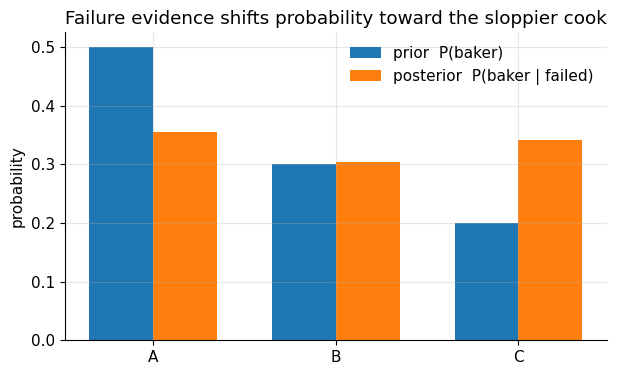

In [7]:
# --- Visualize: prior share vs posterior "blame" ----------------------------
x = np.arange(3); w = 0.35
plt.figure()
plt.bar(x - w/2, share,    w, label="prior  P(baker)")
plt.bar(x + w/2, sim_post, w, label="posterior  P(baker | failed)")
plt.xticks(x, ["A", "B", "C"]); plt.ylabel("probability")
plt.title("Failure evidence shifts probability toward the sloppier cook")
plt.legend(); plt.show()

In [8]:
def cooks(shareA=0.5, shareB=0.3, fA=0.02, fB=0.03, fC=0.05):
    sh = np.array([shareA, shareB, max(1e-9, 1 - shareA - shareB)])
    if sh[2] < 0: print("shares exceed 1 - reduce A or B"); return
    f  = np.array([fA, fB, fC]); pf = sh @ f; post = sh * f / pf
    plt.figure(); x = np.arange(3); w=.35
    plt.bar(x-w/2, sh, w, label="prior"); plt.bar(x+w/2, post, w, label="posterior")
    plt.xticks(x, list("ABC")); plt.ylim(0, 1)
    plt.title(f"P(F) = {pf:.3f}"); plt.legend(); plt.show()

show(cooks,
     shareA=FloatSlider(min=0, max=1, step=.05, value=.5) if HAS_W else .5,
     shareB=FloatSlider(min=0, max=1, step=.05, value=.3) if HAS_W else .3,
     fA=FloatSlider(min=0, max=.2, step=.005, value=.02) if HAS_W else .02,
     fB=FloatSlider(min=0, max=.2, step=.005, value=.03) if HAS_W else .03,
     fC=FloatSlider(min=0, max=.2, step=.005, value=.05) if HAS_W else .05)

interactive(children=(FloatSlider(value=0.5, description='shareA', max=1.0, step=0.05), FloatSlider(value=0.3,…

**Think about it** — (i) Set $f_A=f_B=f_C$. What does the posterior become, and
why? (ii) C bakes the fewest cakes yet often gets the most blame — which two
numbers fight each other in $P(C\mid F)\propto P(C)\,P(F\mid C)$?

---
## Problem 2 — Cancer diagnostic test *(slide p. 14/35)*

> Suppose that there was a cancer diagnostic test that was 95% accurate on
> those that do have cancer and 96% accurate on those who don't. If 0.4% of
> the population have cancer, **compute the probability that a tested person
> has cancer, given that his or her test results indicate so.**

### Model
$D$ = has cancer, $+$ = test positive.
Sensitivity $P(+\mid D)=.95$, specificity $P(-\mid D^c)=.96$
(so the false-positive rate is $P(+\mid D^c)=.04$), prevalence $P(D)=.004$.

$$P(D\mid +)=\frac{P(+\mid D)\,P(D)}{P(+\mid D)\,P(D)+P(+\mid D^c)\,P(D^c)}$$

In [9]:
prev, sens, spec = 0.004, 0.95, 0.96

# Bayes' rule ("PPV" = positive predictive value)
ppv = sens*prev / (sens*prev + (1-spec)*(1-prev))
print(f"P(D | +) = {ppv:.4f}   <- most people guess ~0.95")

P(D | +) = 0.0871   <- most people guess ~0.95


In [10]:
check("P(D|+)", ppv, 0.95*0.004/(0.95*0.004+0.04*0.996), tol=1e-9)

[OK ] P(D|+): got 0.0870761   (reference 0.0870761)


True

Out of 10,000 people:  sick 40  |  TP 38   FP 398   FN 2   TN 9562
Among the 436 positives, only 38 are sick -> 8.7%


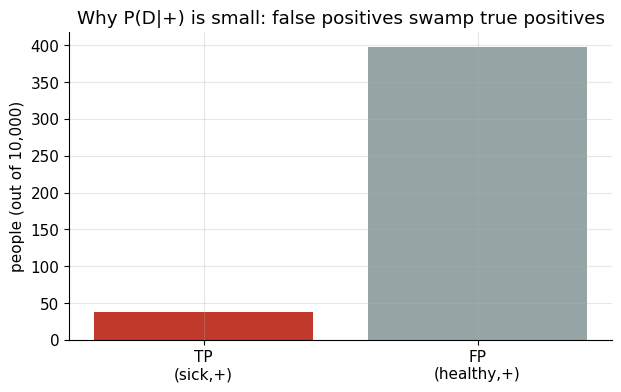

simulated P(D|+) = 0.0872


In [11]:
# --- The honest picture: what happens to 10,000 tested people ---------------
Npop = 10_000
D  = Npop*prev
TP, FN = D*sens, D*(1-sens)
FP, TN = (Npop-D)*(1-spec), (Npop-D)*spec
print(f"Out of {Npop:,} people:  sick {D:.0f}  |  TP {TP:.0f}   FP {FP:.0f}   FN {FN:.0f}   TN {TN:.0f}")
print(f"Among the {TP+FP:.0f} positives, only {TP:.0f} are sick -> {TP/(TP+FP):.1%}")

plt.figure()
plt.bar(["TP\n(sick,+)", "FP\n(healthy,+)"], [TP, FP], color=["#c0392b", "#95a5a6"])
plt.ylabel("people (out of 10,000)")
plt.title("Why P(D|+) is small: false positives swamp true positives")
plt.show()

# Monte-Carlo confirmation
N = 500_000
sick = rng.random(N) < prev
pos  = np.where(sick, rng.random(N) < sens, rng.random(N) < 1-spec)
print(f"simulated P(D|+) = {sick[pos].mean():.4f}")

In [12]:
def ppv_curve(sens=0.95, spec=0.96):
    prevs = np.logspace(-4, np.log10(0.5), 200)
    vals  = sens*prevs / (sens*prevs + (1-spec)*(1-prevs))
    plt.figure()
    plt.semilogx(prevs, vals)
    plt.axvline(0.004, ls="--", c="gray"); plt.annotate("this problem\n(0.4%)",
        (0.004, 0.5), textcoords="offset points", xytext=(8, 0))
    plt.xlabel("prevalence P(D)  (log scale)"); plt.ylabel("P(D | +)")
    plt.title("The same test means different things in different populations")
    plt.ylim(0, 1); plt.show()

show(ppv_curve,
     sens=FloatSlider(min=.5, max=.999, step=.001, value=.95) if HAS_W else .95,
     spec=FloatSlider(min=.5, max=.999, step=.001, value=.96) if HAS_W else .96)

interactive(children=(FloatSlider(value=0.95, description='sens', max=0.999, min=0.5, step=0.001), FloatSlider…

**Think about it** — (i) Which slider raises $P(D\mid+)$ more here:
sensitivity or specificity? Explain using the FP bar. (ii) "The test is 95%
accurate, so a positive person is 95% likely sick" — name the exact fallacy.
*(HW 1 Part B dissects an AI answer that makes it.)*

---
## Problem 3 — Fair coin or two-headed coin? *(slide p. 15/35)*

> A gambler has in his pocket a fair coin and a two-headed coin.
> (a) He selects one of the coins at random, and when he flips it, it shows
> heads. What is the probability that it is the fair coin?
> (b) He flips the same coin a second time and again it shows heads. Now what
> is the probability that it is the fair coin?
> (c) He flips the same coin a third time and it shows tails. Now what is the
> probability that this is the fair coin?

### Model
Prior $P(\text{fair})=\tfrac12$. Given fair, $P(H)=\tfrac12$ per flip
(independent); given two-headed, $P(H)=1$. Update once per observed flip:
$$P(\text{fair}\mid \text{data})=
\frac{P(\text{data}\mid\text{fair})\cdot\frac12}
{P(\text{data}\mid\text{fair})\cdot\frac12+P(\text{data}\mid\text{2H})\cdot\frac12}.$$

In [13]:
def posterior_fair(seq: str) -> float:
    """P(fair | observed flip sequence), e.g. seq='HH' or 'HHT'."""
    like_fair = 0.5 ** len(seq)                       # every flip: 1/2
    like_2h   = 1.0 if "T" not in seq else 0.0        # tails impossible for 2H
    return like_fair * 0.5 / (like_fair * 0.5 + like_2h * 0.5)

for s in ["H", "HH", "HHT"]:
    print(f"P(fair | {s:>3}) = {posterior_fair(s):.4f}")

P(fair |   H) = 0.3333
P(fair |  HH) = 0.2000
P(fair | HHT) = 1.0000


In [14]:
check("(a) P(fair|H)",   posterior_fair("H"),   1/3, tol=1e-9)
check("(b) P(fair|HH)",  posterior_fair("HH"),  1/5, tol=1e-9)
check("(c) P(fair|HHT)", posterior_fair("HHT"), 1.0, tol=1e-9)

[OK ] (a) P(fair|H): got 0.333333   (reference 0.333333)
[OK ] (b) P(fair|HH): got 0.2   (reference 0.2)
[OK ] (c) P(fair|HHT): got 1   (reference 1)


True

In [15]:
# --- Simulate: filter runs whose first flips match the observed prefix ------
N = 400_000
fair  = rng.random(N) < 0.5
flips = np.where(fair[:, None], rng.random((N, 3)) < 0.5, True)   # H=True

for k, label in [(1, "H"), (2, "HH")]:
    match = flips[:, :k].all(axis=1)
    print(f"simulated P(fair | {label:>2}) = {fair[match].mean():.4f}")
match = flips[:, 0] & flips[:, 1] & ~flips[:, 2]                  # H,H,T
print(f"simulated P(fair | HHT) = {fair[match].mean():.4f}")

simulated P(fair |  H) = 0.3340
simulated P(fair | HH) = 0.2004
simulated P(fair | HHT) = 1.0000


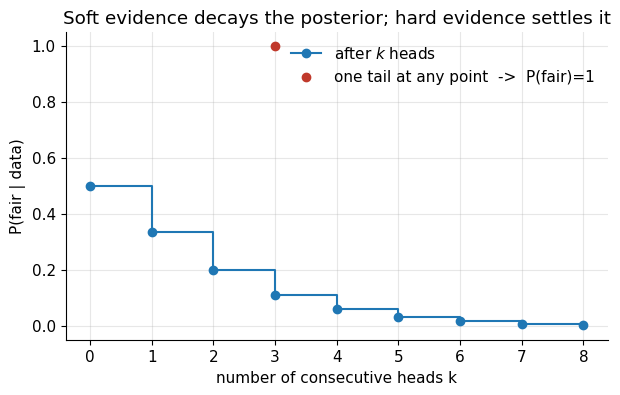

In [16]:
# --- Evidence accumulates ... until one tail ends the debate ----------------
ks = np.arange(0, 9)
post_heads = (0.5**ks) / (0.5**ks + 1)      # P(fair | k heads in a row)

plt.figure()
plt.step(ks, post_heads, where="post", marker="o", label=r"after $k$ heads")
plt.scatter([3], [1.0], zorder=5, color="#c0392b",
            label="one tail at any point  ->  P(fair)=1")
plt.xlabel("number of consecutive heads k"); plt.ylabel("P(fair | data)")
plt.title("Soft evidence decays the posterior; hard evidence settles it")
plt.legend(); plt.ylim(-0.05, 1.05); plt.show()

**Think about it** — (i) Posterior odds after $k$ heads are
$\left(\tfrac12\right)^k$: each head multiplies the odds for "fair" by exactly
$\tfrac12$. Why the *likelihood ratio*? (ii) In (c) a single tail outweighs any
number of heads. What property of the two-headed hypothesis makes its
posterior exactly 0, not just small?

---
## Problem 4 — Picking lathes *(slide p. 19/35)*

> A company has 7 machines on its shop-floor of which 4 are lathes. The
> service personnel pick two machines at random and check to see if they have
> any maintenance problems. Let $X$ be the number of lathes selected.
> **Find the probability mass function of $X$. Verify that all properties of
> PMFs are satisfied.**

### Model
Sampling **without replacement** — the classic *hypergeometric* setting:
$$P(X=k)=\frac{\binom{4}{k}\binom{3}{2-k}}{\binom{7}{2}},\qquad k=0,1,2 .$$

In [17]:
from math import comb

pmf = np.array([comb(4, k) * comb(3, 2-k) / comb(7, 2) for k in range(3)])
EX  = float((np.arange(3) * pmf).sum())

print("pmf  =", pmf, " (as fractions: 1/7, 4/7, 2/7)")
print(f"sum  = {pmf.sum():.6f}   (must be 1)")
print(f"E[X] = {EX:.4f}          (= 2 x 4/7)")

pmf  = [0.14285714 0.57142857 0.28571429]  (as fractions: 1/7, 4/7, 2/7)
sum  = 1.000000   (must be 1)
E[X] = 1.1429          (= 2 x 4/7)


In [18]:
check("sum pmf", None if pmf is Ellipsis else float(np.sum(pmf)), 1.0, tol=1e-9)
check("E[X]",    EX, 8/7, tol=1e-9)

[OK ] sum pmf: got 1   (reference 1)
[OK ] E[X]: got 1.14286   (reference 1.14286)


True

enumeration pmf = [0.14285714 0.57142857 0.28571429]


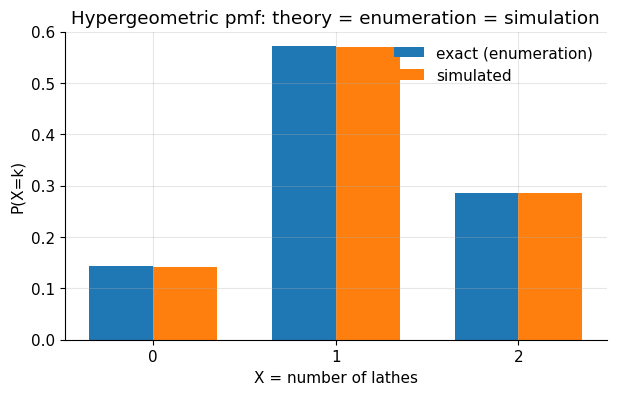

In [19]:
# --- Two independent confirmations ------------------------------------------
# (1) Exact enumeration of all C(7,2)=21 equally likely pairs
from itertools import combinations
machines = ["L1","L2","L3","L4","M1","M2","M3"]          # 4 lathes, 3 others
counts = np.zeros(3)
for pair in combinations(machines, 2):
    counts[sum(m.startswith("L") for m in pair)] += 1
print("enumeration pmf =", counts / counts.sum())

# (2) Monte-Carlo sampling without replacement
sim = rng.hypergeometric(ngood=4, nbad=3, nsample=2, size=200_000)
emp = np.bincount(sim, minlength=3) / len(sim)

x = np.arange(3); w=.35
plt.figure()
plt.bar(x-w/2, counts/21, w, label="exact (enumeration)")
plt.bar(x+w/2, emp,       w, label="simulated")
plt.xticks(x); plt.xlabel("X = number of lathes"); plt.ylabel("P(X=k)")
plt.title("Hypergeometric pmf: theory = enumeration = simulation")
plt.legend(); plt.show()

**Think about it** — (i) Which PMF property did the `sum = 1` line verify, and
which property do the bar heights verify? (ii) If instead each pick were made
*with replacement* the pmf would be Binomial$(2, 4/7)$ — which $k$ gains
probability and why? *(HW 1 Part C-2 makes this precise.)*

---
## Problem 5 — 85% yield, 50 parts *(slide p. 23/35)*

> Historical data has revealed that a manufacturer's current yield is 85%.
> That is 15% of the parts they produce are defective. If 50 parts are
> produced:
> (a) What is the probability that exactly 8 parts are defective in total?
> (b) What is the probability that the 10th part produced is the first
> defective item?
> (c) What is the probability that the 20th part produced is the third
> defective part?

### Model — one Bernoulli(0.15) process, three questions
| question | counts what | distribution |
|---|---|---|
| (a) # defects in 50 | successes in fixed n | Binomial$(50, .15)$ |
| (b) trial of 1st defect | waiting time to 1st | Geometric$(.15)$ |
| (c) trial of 3rd defect | waiting time to 3rd | Negative Binomial |

$(a)\ \binom{50}{8}p^8q^{42}\qquad (b)\ q^{9}p\qquad (c)\ \binom{19}{2}p^3q^{17}$, with $p=.15,\ q=.85$.

In [20]:
from math import comb
p, q = 0.15, 0.85

p_a = comb(50, 8) * p**8 * q**42       # Binomial
p_b = q**9 * p                          # Geometric (1st success on trial 10)
p_c = comb(19, 2) * p**3 * q**17        # Negative Binomial (3rd on trial 20)

print(f"(a) P(exactly 8 defective in 50) = {p_a:.4f}")
print(f"(b) P(10th part is 1st defect)   = {p_b:.4f}")
print(f"(c) P(20th part is 3rd defect)   = {p_c:.4f}")

(a) P(exactly 8 defective in 50) = 0.1493
(b) P(10th part is 1st defect)   = 0.0347
(c) P(20th part is 3rd defect)   = 0.0364


In [21]:
check("(a)", p_a, stats.binom.pmf(8, 50, 0.15), tol=1e-12)
check("(b)", p_b, 0.85**9 * 0.15,                 tol=1e-12)
check("(c)", p_c, stats.nbinom.pmf(20-3, 3, 0.15), tol=1e-12)

[OK ] (a): got 0.149349   (reference 0.149349)
[OK ] (b): got 0.0347425   (reference 0.0347425)
[OK ] (c): got 0.0364243   (reference 0.0364243)


np.True_

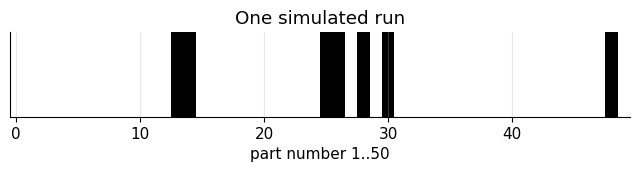

(a) sim 0.1502   vs analytic 0.1493
(b) sim 0.0345   vs analytic 0.0347
(c) sim 0.0366   vs analytic 0.0364


In [22]:
# --- ONE production line, THREE distributions --------------------------------
runs = rng.random((100_000, 50)) < 0.15          # True = defective

# one sample run, drawn as a strip: dark = defective
plt.figure(figsize=(8, 1.1))
plt.imshow(runs[0][None, :], cmap="Greys", aspect="auto")
plt.yticks([]); plt.xlabel("part number 1..50"); plt.title("One simulated run")
plt.show()

n_def = runs.sum(axis=1)                                          # (a)
first = np.where(runs.any(1), runs.argmax(1) + 1, 51)             # (b)
c3    = (runs.cumsum(1) == 3) & runs
third = np.where(runs.sum(1) >= 3, c3.argmax(1) + 1, 51)          # (c)

print(f"(a) sim {np.mean(n_def == 8):.4f}   vs analytic {p_a:.4f}")
print(f"(b) sim {np.mean(first == 10):.4f}   vs analytic {p_b if p_b is not Ellipsis else float('nan'):.4f}")
print(f"(c) sim {np.mean(third == 20):.4f}   vs analytic {p_c if p_c is not Ellipsis else float('nan'):.4f}")

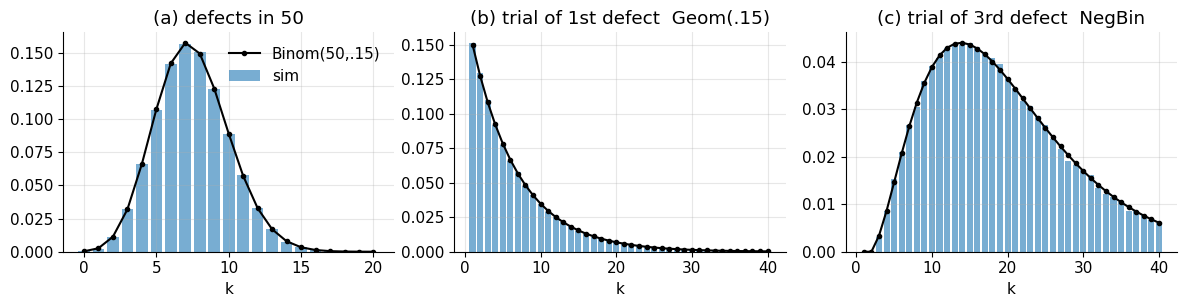

In [23]:
# --- Overlay empirical vs theoretical for all three --------------------------
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))

ks = np.arange(0, 21)
ax[0].bar(ks, [np.mean(n_def == k) for k in ks], alpha=.6, label="sim")
ax[0].plot(ks, stats.binom.pmf(ks, 50, .15), "k.-", label="Binom(50,.15)")
ax[0].set_title("(a) defects in 50"); ax[0].legend()

ts = np.arange(1, 41)
ax[1].bar(ts, [np.mean(first == t) for t in ts], alpha=.6)
ax[1].plot(ts, stats.geom.pmf(ts, .15), "k.-")
ax[1].set_title("(b) trial of 1st defect  Geom(.15)")

ax[2].bar(ts, [np.mean(third == t) for t in ts], alpha=.6)
ax[2].plot(ts, stats.nbinom.pmf(ts - 3, 3, .15), "k.-")
ax[2].set_title("(c) trial of 3rd defect  NegBin")
for a in ax: a.set_xlabel("k")
plt.tight_layout(); plt.show()

In [24]:
def yield_effect(good=0.85):
    pp = 1 - good; ks = np.arange(0, 26); ts = np.arange(1, 41)
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(ks, stats.binom.pmf(ks, 50, pp), "o-")
    ax[0].set_title(f"(a) # defects in 50   E = {50*pp:.1f}")
    ax[1].plot(ts, stats.geom.pmf(ts, pp), "o-")
    ax[1].set_title(f"(b) trial of 1st defect   E = {1/pp:.1f}")
    for a in ax: a.set_xlabel("k")
    plt.tight_layout(); plt.show()

show(yield_effect, good=FloatSlider(min=.5, max=.99, step=.01, value=.85) if HAS_W else .85)

interactive(children=(FloatSlider(value=0.85, description='good', max=0.99, min=0.5, step=0.01), Output()), _d…

**Think about it** — (i) All three answers came from the *same* 0/1 sequence.
State in one sentence what each of (a)(b)(c) *conditions on or counts*.
(ii) As yield → 99%, which plot stretches out faster, (a) or (b)? Connect to
$E[\text{Geom}] = 1/p$ *(proved via the tail-sum formula — Companion Proof 3).*

---
## Problem 6 — Cars at a yield sign *(slide p. 24/35)*

> Cars arrive at a certain yield sign on a road according to a Poisson
> distribution with $\lambda = 8$ cars in a minute.
> (a) What is the probability that exactly 5 cars arrive in a minute?
> (b) What is the probability that more than 2 cars arrive in a minute?

### Model
$X\sim\text{Poisson}(8)$:  $P(X=k)=e^{-8}\,8^k/k!$, and
$P(X>2)=1-\sum_{k=0}^{2}P(X=k)$.

In [25]:
lam = 8
p5 = math.exp(-lam) * lam**5 / math.factorial(5)
p_more2 = 1 - math.exp(-lam) * (1 + lam + lam**2/2)

print(f"(a) P(X=5) = {p5:.4f}")
print(f"(b) P(X>2) = {p_more2:.4f}")

(a) P(X=5) = 0.0916
(b) P(X>2) = 0.9862


In [26]:
check("(a) P(X=5)", p5, stats.poisson.pmf(5, 8), tol=1e-12)
check("(b) P(X>2)", p_more2, 1 - stats.poisson.cdf(2, 8), tol=1e-12)

[OK ] (a) P(X=5): got 0.0916037   (reference 0.0916037)
[OK ] (b) P(X>2): got 0.986246   (reference 0.986246)


np.True_

sim (a) 0.0909    sim (b) 0.9862


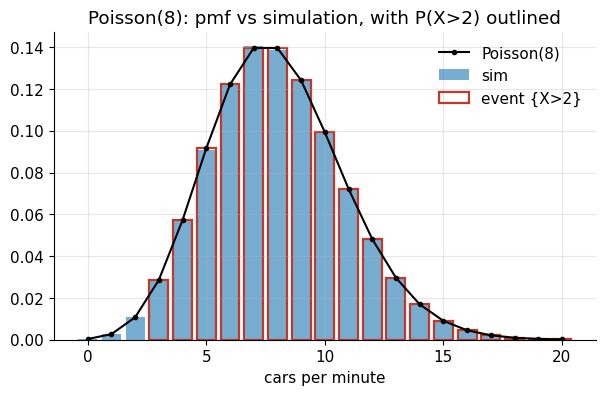

In [27]:
sim = rng.poisson(8, 300_000)
print(f"sim (a) {np.mean(sim == 5):.4f}    sim (b) {np.mean(sim > 2):.4f}")

ks = np.arange(0, 21)
plt.figure()
plt.bar(ks, np.bincount(sim, minlength=21)[:21] / len(sim), alpha=.6, label="sim")
plt.plot(ks, stats.poisson.pmf(ks, 8), "k.-", label="Poisson(8)")
mask = ks > 2
plt.bar(ks[mask], stats.poisson.pmf(ks[mask], 8), color="none",
        edgecolor="#c0392b", lw=1.6, label="event {X>2}")
plt.xlabel("cars per minute"); plt.legend()
plt.title("Poisson(8): pmf vs simulation, with P(X>2) outlined")
plt.show()

**Preview (Ch.5):** here $\lambda=8/\text{min}$ is a *rate* — soon we treat
arrivals as a **Poisson process** in time, where counts over any window of
length $t$ are Poisson$(\lambda t)$ and inter-arrival gaps are Exponential.
Class Problem 6 (East Gate intersection) revisits exactly this setting.

---
## Wrap-up

| # | setting | law used | key number |
|---|---|---|---|
| 1 | cooks | total prob + Bayes | $P(A\mid F)=.345$ |
| 2 | cancer test | Bayes, base rate | $P(D\mid +)\approx .087$ |
| 3 | two coins | sequential Bayes | $\tfrac13,\ \tfrac15,\ 1$ |
| 4 | lathes | hypergeometric | pmf $\left(\tfrac17,\tfrac47,\tfrac27\right)$ |
| 5 | yield 85% | binom / geom / negbin | one process, 3 views |
| 6 | cars | Poisson | $P(X>2)=.986$ |

**Next steps** → Companion Ch.1–3 (Proofs 1–6, gap-fill first) → HW 1
(Part A *without* AI first).